In [1]:
# Import relevant packages
import worldtube_postprocess as wpp
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline
from spectre.SphericalHarmonics import SpherepackIterator
import h5py
import sys, os
import glob

## Trajectory Code Block

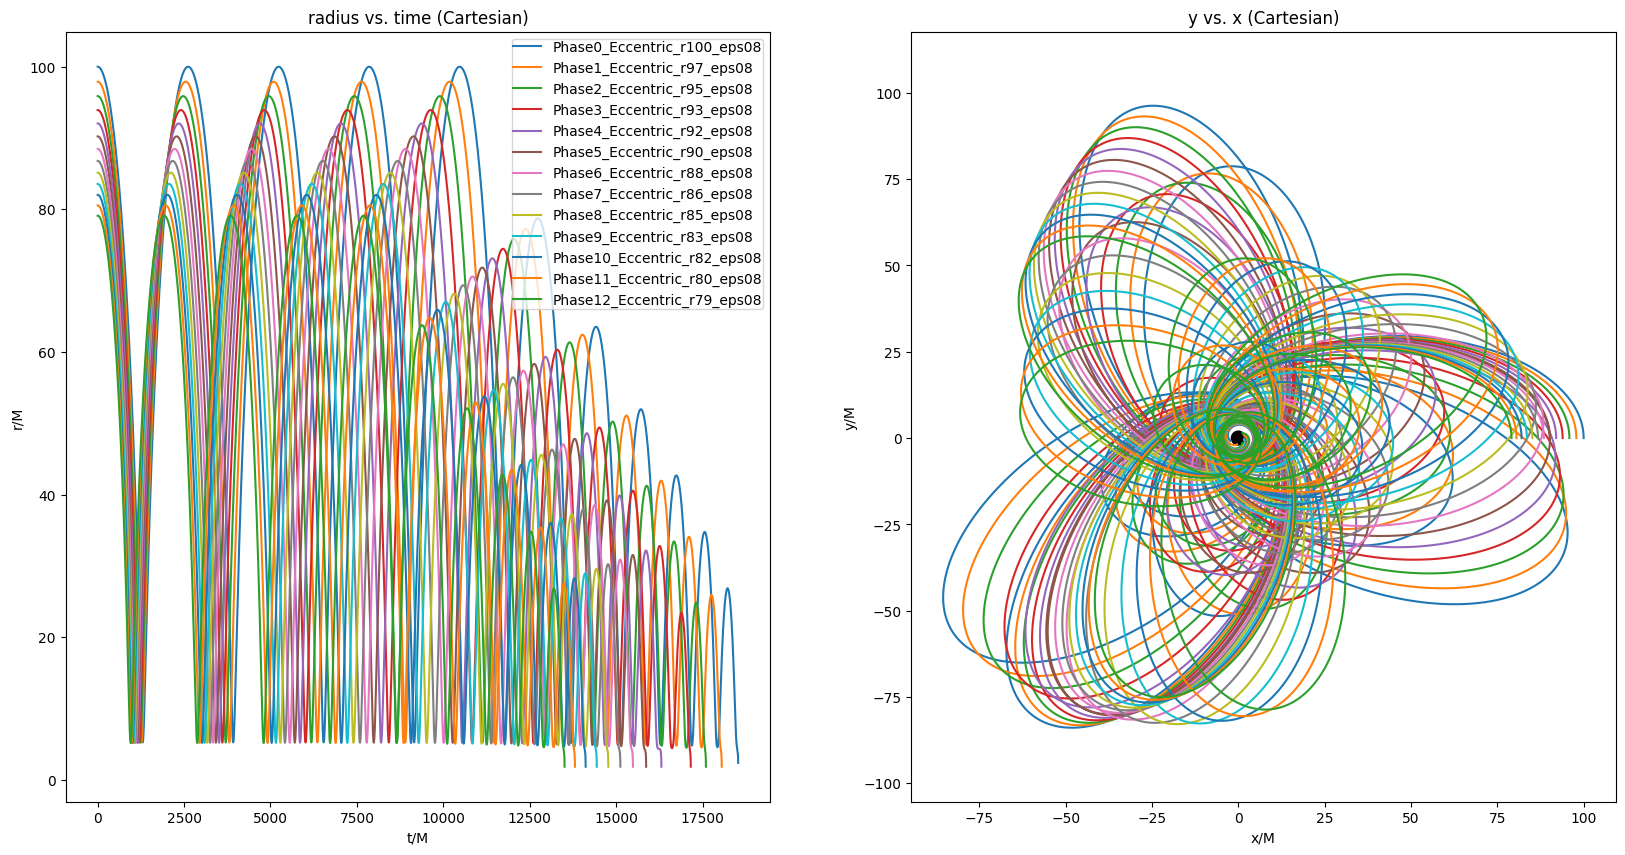

In [2]:
# Extract out the simulation data for trajectory plot
file_list = sorted(
    glob.glob("Phase*_Eccentric*"),
    key=lambda x: int(os.path.basename(x).split("_")[2].split("r")[1]),
    reverse=True,
)
sim_data = {n: wpp.extract_sim_data(n) for n in file_list}
traj_pos = [sim_data[n]["position"] for n in file_list]
time = [sim_data[n]["times"] for n in file_list]
radii = [sim_data[n]["radii"] for n in file_list]

# Plot the trajectory
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
# ax[1]=plt.subplot(122,projection='polar')
labellist = [
    ["t/M", "r/M", "radius vs. time (Cartesian)"],
    ["x/M", "y/M", "y vs. x (Cartesian)"],
]
for n, row in enumerate(ax):
    row.set_xlabel(labellist[n][0])
    row.set_ylabel(labellist[n][1])
    row.set_title(labellist[n][2])
for i, n in enumerate(file_list):
    ax[1].plot(traj_pos[i][:, 0], traj_pos[i][:, 1], "-", label=n, markersize=1)
    ax[0].plot(time[i], radii[i], label=n)
    # ax[0].set_ylim([8-1e-4,8+1e-4])  # Adjust the y-limits to zoom in on the radius
    # ax[0].set_xlim([0,1000])
plt.axis("equal")
event_horizon = plt.Circle((0, 0), radius=2, color="k")
ax[1].add_patch(event_horizon)
ax[0].legend(loc="upper right", borderpad=0.1)
# ax[0].set_ylim([2,8])
# ax[0].set_xlim(6000)
plt.savefig("trajectory_plot.png", bbox_inches="tight")
plt.show()

t_ref: [np.float64(15728.697651616088), np.float64(15207.597444096213), np.float64(14709.968934399982), np.float64(14229.963888677567), np.float64(13810.473026228901), np.float64(13372.528937730378), np.float64(12946.808453487707), np.float64(12540.81322138976), np.float64(12147.03153217928), np.float64(11771.834763428518), np.float64(11404.784529171659), np.float64(11052.20487924776), np.float64(10709.781753809188)]


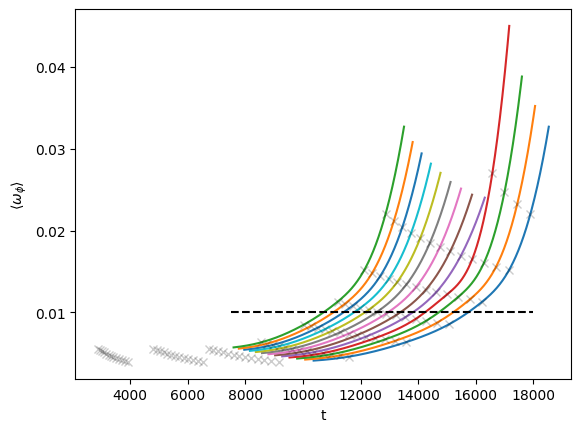

In [3]:
# Find minima of radii and inflection point of eccentricity
def stationary_points(data_list, time_list, type="infl"):
    """Find the stationary points of a given type from the data after smoothing"""
    first_der = np.gradient(data_list, time_list)
    second_der = np.gradient(first_der, time_list)

    if type == "infl":
        stat_pts = (np.roll(np.sign(second_der), 1) != np.sign(second_der)) | (
            np.sign(second_der) == 0
        )
    if type == "min":
        stat_pts = (np.roll(np.sign(first_der), 1) != np.sign(first_der)) & (
            second_der > 0
        )
    else:
        stat_pts = (np.roll(np.sign(first_der), 1) != np.sign(first_der)) & (
            second_der < 0
        )

    return data_list[stat_pts], time_list[stat_pts], stat_pts


# Compute the angular frequency for all the plots
def avg_omega(
    traj=traj_pos, t=time, tsf=[sim_data[n]["turn_on_time"] for n in file_list]
):
    """Compute the average angular frequency of the trajectory"""
    r = [np.sqrt(tr[:, 0] ** 2 + tr[:, 1] ** 2) for tr in traj]
    omega_avg = []
    t_avg = []
    t_ref = []
    for i, tr in enumerate(traj):
        r_apo, t_apo, i_apo = stationary_points(r[i], t[i], "max")
        phi = np.unwrap(np.angle(tr[:, 0] + tr[:,1] * 1j))
        phi_apo = phi[i_apo]
        omega = np.diff(phi_apo) / np.diff(t_apo)
        omega_interp = CubicSpline((t_apo[1:] + t_apo[:-1]) / 2, omega)(t[i])
        omega_avg.append(omega_interp[t[i] > tsf[i]])
        t_avg.append(t[i][t[i] > tsf[i]])
        # print(omega_avg)

        omega_ref = 0.01
        t_ref.append(t_avg[i][abs(omega_avg[i] - omega_ref).argmin()])
        plt.plot(t_avg[i], omega_avg[i], label=file_list[i])
        plt.plot((t_apo[1:] + t_apo[:-1]) / 2, omega, "kx", alpha=0.2)

    print(f"t_ref: {t_ref}")
    plt.hlines(omega_ref, 7500, 18000, color="k", linestyle="--", label=r"$10^{-3}$")
    # plt.legend()
    plt.xlabel("t")
    # plt.ylim(omega_ref)
    plt.ylabel(r"$\left<\omega_\phi\right>$")
    plt.savefig("omega_avg.pdf", bbox_inches="tight")
    plt.show()

    return t_ref


t_ref_list = avg_omega()

## Keplerian Parameters Code Block

Fraction of data points with 3 real roots: 0.9129500457972239
Fraction of data points with 3 real roots: 0.9009423859498822
Fraction of data points with 3 real roots: 0.8975775761124122
Fraction of data points with 3 real roots: 0.8915536628189323
Fraction of data points with 3 real roots: 0.9720883127405306
Fraction of data points with 3 real roots: 0.9420852716486706
Fraction of data points with 3 real roots: 0.9349921149465569
Fraction of data points with 3 real roots: 0.9284365728670323
Fraction of data points with 3 real roots: 0.9079584775086506
Fraction of data points with 3 real roots: 0.8991823037292622
Fraction of data points with 3 real roots: 0.8953662906115334
Fraction of data points with 3 real roots: 0.8927705477757435
Fraction of data points with 3 real roots: 0.8917837675651348


/urania/ptmp/cditt/worldtube_run/evolution_analysis_runs/worldtube_postprocess.py:254: RuntimeWarning: invalid value encountered in sqrt
  theta = np.arccos(3 * bigq / (2 * bigp) * np.sqrt(-3 / bigp))
/urania/ptmp/cditt/worldtube_run/evolution_analysis_runs/worldtube_postprocess.py:254: RuntimeWarning: invalid value encountered in arccos
  theta = np.arccos(3 * bigq / (2 * bigp) * np.sqrt(-3 / bigp))
/urania/ptmp/cditt/worldtube_run/evolution_analysis_runs/worldtube_postprocess.py:255: RuntimeWarning: invalid value encountered in sqrt
  amp = 2 * np.sqrt(-bigp / 3)


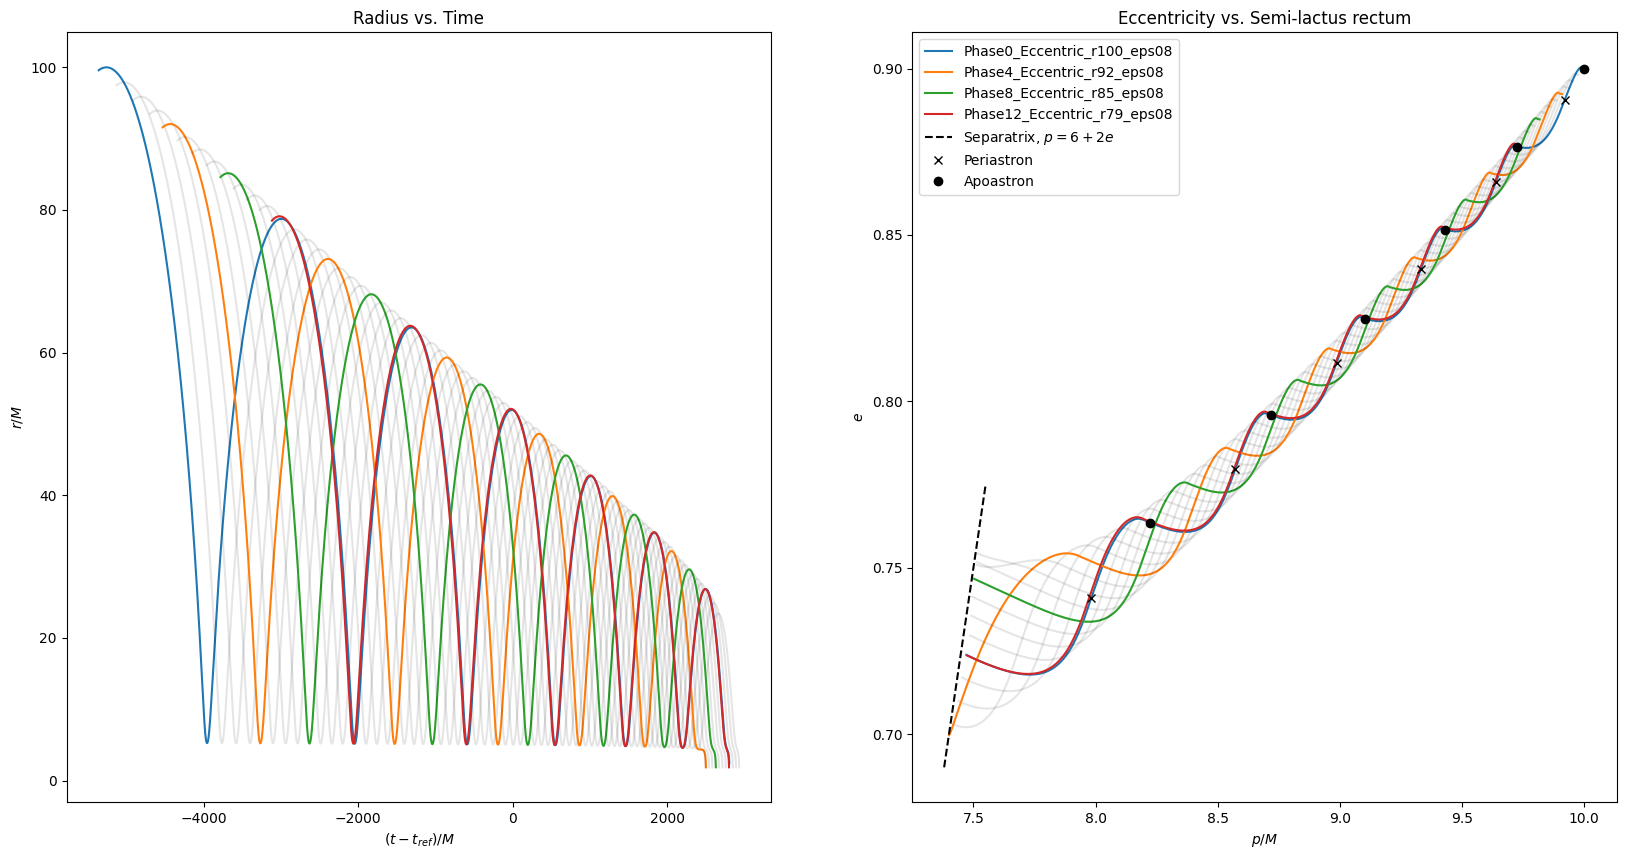

In [ ]:
# Generate the p,e plot for inspirals
osc_data = {n: wpp.get_osculating_elements(sim_data[n]) for n in file_list}

# Find the apoastron times and values
apoastron_val, apoastron_pts, apoastron_index = stationary_points(
    radii[0], time[0], "max"
)
periastron_val, periastron_pts, periastron_index = stationary_points(
    radii[0], time[0], "min"
)
pe_data, pe_pts, pe_index = stationary_points(
    osc_data[file_list[0]][3], osc_data[file_list[0]][2], "infl"
)

turn_on_time = [sim_data[n]["turn_on_time"] for n in file_list]
# Plot the values versus time
f, ax = plt.subplots(1, 2, figsize=(20, 10))
for i, n in enumerate(file_list):
    if i % 4 == 0:
        
        ax[0].plot(time[i][time[i]>turn_on_time[i]] - t_ref_list[i], radii[i][time[i]>turn_on_time[i]], label=n)
    else:
        ax[0].plot(time[i][time[i]>turn_on_time[i]] - t_ref_list[i], radii[i][time[i]>turn_on_time[i]], "k-", alpha=0.1)

ax[0].set_xlabel(r"$(t-t_{ref})/M$")
ax[0].set_ylabel(r"$r/M$")
ax[0].set_title(rf"Radius vs. Time")

# Plot our osculating elements
for i, key in enumerate(osc_data):
    if i % 4 == 0:
        ax[1].plot(osc_data[key][2], osc_data[key][3], label=rf"{key}")
    else:
        ax[1].plot(osc_data[key][2], osc_data[key][3], "k-", alpha=0.1)

p_sep = np.linspace(7.38, 7.55, 100)
e_sep = (p_sep - 6) / 2
ax[1].plot(p_sep, e_sep, "k--", label=r"Separatrix, $p=6+2e$")

pe_bool = [
    np.where(np.isin(osc_data[file_list[0]][4], stat))[0]
    for stat in (periastron_pts, apoastron_pts)
]
pe_stat = [
    [data[stat] for data in [osc_data[file_list[0]][2], osc_data[file_list[0]][3]]]
    for stat in pe_bool
]
ax[1].plot(pe_stat[0][0], pe_stat[0][1], "xk", label="Periastron")
ax[1].plot(pe_stat[1][0], pe_stat[1][1], "ok", label="Apoastron")
ax[1].set_ylabel(r"$e$")
ax[1].set_xlabel(r"$p/M$")
ax[1].set_title(r"Eccentricity vs. Semi-lactus rectum")
ax[1].legend()
plt.savefig("semi-ecc_plot.pdf", bbox_inches="tight")
plt.show()

In [ ]:
from fractions import Fraction

def pe_fit(p,*consts):
    m,c=consts
    return m*p+c

def phase_controller(phase,stat_pts):
    x_list=stat_pts[0]
    y_list=stat_pts[1]
    [m,c], _= curve_fit(pe_fit,x_list[:-2],y_list[:-2],p0=[1.,0.1])
    
    plt.plot(x_list,y_list,'x',label='Apoastron')
    plt.plot(x_list,m*x_list+c,'--',label='Fitted line')

    y0=y_list[0]
    x0=x_list[0]
    Dx=x_list[1]-x_list[0]
    diff=phase*Dx

    x_new=x0+diff
    y_new=m*diff+y0

    plt.plot(x_new,y_new,'ko',label='Chosen point')
    plt.xlabel(r'$p/M$')
    plt.ylabel(r'$e$')
    plt.title(r'Eccentricity vs. Semi-lactus rectum')
    plt.legend()
    plt.show()

    print(f"Phase: {Fraction(phase).limit_denominator()}")
    print(f"Choose these starting values for the input file: {x_new},{y_new}")
    pass

#Execute for apoastron
for n in range(1,13):
    phase_controller(n/12,pe_stat[1])

## Conserved Quantities Code Block

Phase0_Eccentric_r100_eps08 2.39282230366189
Phase1_Eccentric_r97_eps08 1.8527428316505206
Phase2_Eccentric_r95_eps08 1.854261517228555
Phase3_Eccentric_r93_eps08 1.8545840932502375
Phase4_Eccentric_r92_eps08 1.8542929433259612
Phase5_Eccentric_r90_eps08 1.8534006532862444
Phase6_Eccentric_r88_eps08 1.8543403890641403
Phase7_Eccentric_r86_eps08 1.8537186331930173
Phase8_Eccentric_r85_eps08 1.8548183378357999
Phase9_Eccentric_r83_eps08 1.8548874523157433
Phase10_Eccentric_r82_eps08 1.853449930606992
Phase11_Eccentric_r80_eps08 1.854409272644288
Phase12_Eccentric_r79_eps08 1.8542914459203954


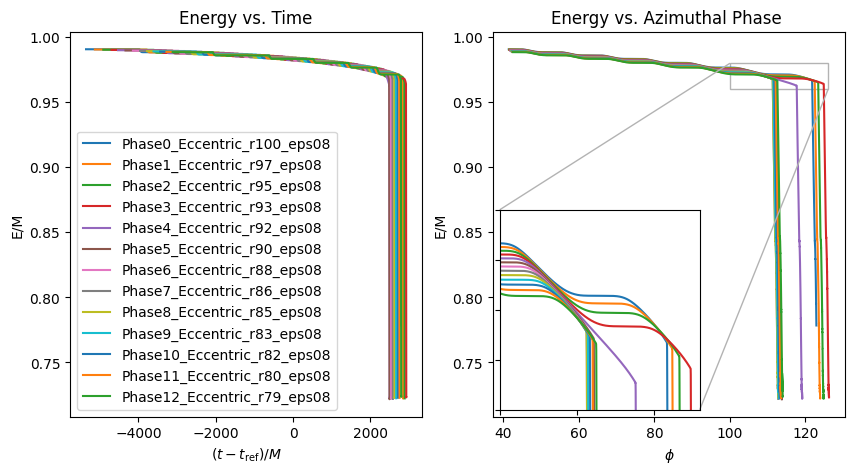

In [20]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset


# Compute the angular frequency for all the plots
def energy_phase_plot(
    traj=traj_pos,
    E=[sim_data[n]["energy"] for n in file_list],
    t=time,
    tsf=[sim_data[n]["turn_on_time"] for n in file_list],
):
    """Compute the average angular frequency of the trajectory"""
    phi = []
    t_list = []
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    axins = inset_axes(ax[1], 2, 2, loc="lower left")
    mark_inset(ax[1], axins, loc1=2, loc2=4, ec="0.7")

    for i, tr in enumerate(traj):
        mask = t[i] > tsf[i]
        phi = np.unwrap(np.angle(tr[:, 0] + tr[:, 1] * 1j))
        ax[0].plot(t[i][mask] - t_ref_list[i], E[i][mask], label=file_list[i])
        ax[1].plot(phi[mask], E[i][mask], label=file_list[i])
        axins.plot(phi[E[i] > 0.95], E[i][E[i] > 0.95])
        print(file_list[i], np.sqrt(tr[:, 1] ** 2 + tr[:, 0] ** 2)[-1])
    # Create inset
    x1, x2, y1, y2 = 100, 126, 0.96, 0.98
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_box_aspect(1)
    axins.set_xticklabels([])
    axins.set_yticklabels([])

    ax[0].set_xlabel(r"$(t-t_\text{ref})/M$")
    ax[0].set_ylabel("E/M")
    ax[0].legend()
    ax[0].set_title("Energy vs. Time")
    ax[1].set_ylabel("E/M")
    ax[1].set_xlabel(r"$\phi$")
    ax[1].set_title(r"Energy vs. Azimuthal Phase ")
    plt.savefig("energy_phase_plot.pdf", bbox_inches="tight")
    plt.show()
    pass


energy_phase_plot()

## Field Strength Code Block

In [ ]:
final_index=2

#Extract out the simulation data for spherical harmonic modes
full_sphere_data = {n:wpp.extract_sphere_data(n) for n in file_list[:]}
time_sph = {n:full_sphere_data[n][0] for n in file_list[:]}
sphere_pack = {n:full_sphere_data[n][1] for n in file_list[:]}
sphere_radii = {n:full_sphere_data[n][2] for n in file_list[:]}

#Extract out the l_max value for the simulation 
# Get lmax from datafile
with h5py.File(f"{file_list[0]}/Reductions.h5", "r") as h5file:
    dat_file = h5file.get("/Spheres_Ylm.dat")
    legend = list(dat_file.attrs["Legend"])
    lmax = int(dat_file[0, legend.index("Lmax")])
    print("lmax : ", lmax)

# print(radii)
# print(sphere_pack.shape,time_sph.shape)

lmax :  10


The (l,m) modes are: [(0, 0), (1, 0), (1, 1), (2, 0), (2, 1), (2, 2)]


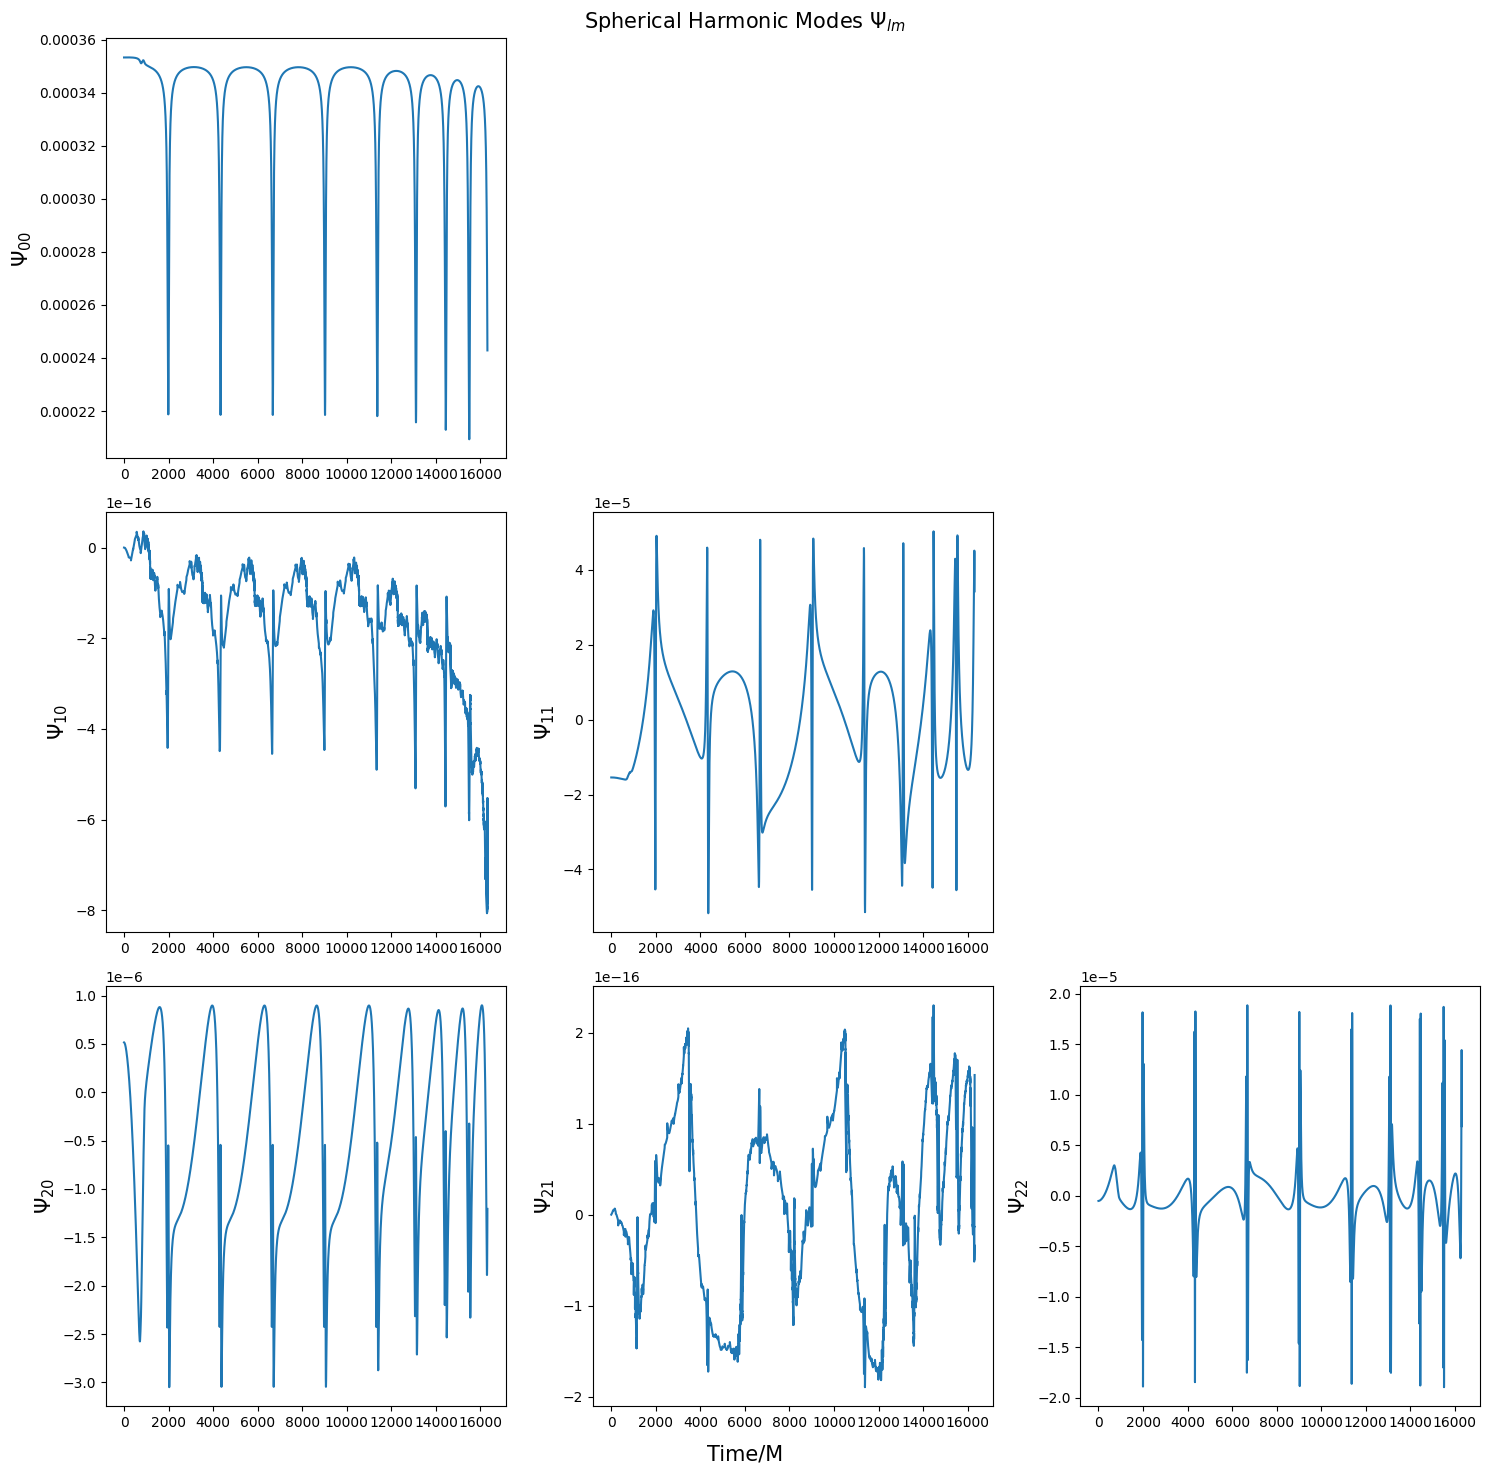

In [68]:
#Plot the spherical harmonic modes
#Generate the modes to plot
lmodes = range(3)
lm_modes = [(l_temp, m) for l_temp in lmodes for m in range(0,l_temp+1)]
print('The (l,m) modes are:',lm_modes)

#Extract out the Psi_lm modes from the data
Psi_dict={n:{(l,m):[time_sph[n],wpp.ylm(data=sphere_pack[n][0],l=l,m=m,l_max=lmax)] for (l,m) in lm_modes} for n in file_list[:]}

#Plot the modes
fig,ax=plt.subplots(lm_modes[-1][0]+1,lm_modes[-1][1]+1,figsize=(15,15))
for l in range(lm_modes[-1][0]+1):
    for m in range(lm_modes[-1][1]+1):
        if l<m:
            ax[l][m].axis('off')  # Hide the subplot if l < m
        else:
            ax[l][m].plot(Psi_dict[file_list[4]][(l,m)][0],Psi_dict[file_list[4]][(l,m)][1],label=f'l={l}, m={m}')
            ax[l][m].set_ylabel(rf'$\Psi_{{{l}{m}}}$',fontsize=15)
fig.suptitle(r'Spherical Harmonic Modes $\Psi_{lm}$', fontsize=15)
fig.supxlabel('Time/M', fontsize=15)
plt.tight_layout()
plt.savefig('spherical_harmonic_modes.png',bbox_inches='tight')
plt.show()


## Convergence Code Block

In [ ]:
#Extracting Psi_00 for t_choice
Psi_00_stable={}
t_choice=3000
for n in file_list[:]:
    t_stable=np.argmin(abs(Psi_dict[n][(0,0)][0]-t_choice))
    Comparison_val=[Psi_dict[n][(0,0)][0][t_stable],Psi_dict[n][(0,0)][1][t_stable]]
    Psi_00_stable[n]=Comparison_val
# print(Psi_00_400)

#Create our Error of Psi^R with Psi^R_ref
WT_Radius=np.zeros((len(file_list[:]),2))
WT_Radius[:,0]=[0.2,0.4,0.8,1.6,2.0]
for i,n in enumerate(file_list[:]):
    WT_Radius[i,1]=abs(Psi_00_stable[n][1]/Psi_00_stable[file_list[0]][1]-1)
print('WT_Radius:',WT_Radius)

#Fitting for the values
def fit_func(wt, a, b):
    return b * (wt ** a)
popt,pcov=curve_fit(fit_func,WT_Radius[1:,0],WT_Radius[1:,1],p0=[1.2,1e-4])
print(r"\alpha, A:",popt)
fit=popt[1]*(WT_Radius[1:,0]**popt[0])

#Plot the convergence of Psi^R
plt.plot(WT_Radius[1:,0],WT_Radius[1:,1],'x',label='Data')
# plt.plot(WT_Radius[1:,0],WT_Radius[1,1]*(WT_Radius[1:,0]/WT_Radius[1,0])**1.2,'--',label='Manual Fit')
plt.plot(WT_Radius[1:,0],fit,'--',label='Curve Fit')

plt.text(1,5e-5,rf'$\alpha={popt[0]:.2f}$',fontsize=10,color='orange')
plt.xlabel('WT Radius R')
plt.ylabel(r'$|\frac{\Psi^\mathcal{R}-\Psi^\mathcal{R}_{ref}}{\Psi^\mathcal{R}_{ref}}|$')
plt.yscale('log')
plt.xscale('log')
plt.title(rf'Convergence of $\Psi^\mathcal{{R}}$ @ t={t_choice}M')
plt.legend()
plt.show()
plt.savefig('convergence_plot.png',bbox_inches='tight')

In [ ]:
#Save the data for later use when combining plots.
file_name = sys.argv[1]  # Use the provided file name
file_name += '.txt'
file_path = '/urania/ptmp/cditt/worldtube-kerr/8M_circular/'
with open(file_path+file_name,'w') as f:
    np.savetxt(f,[popt])
    f.write('\n')
    np.savetxt(f,WT_Radius)

## Animation Code Block

In [5]:
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation
import matplotlib.animation

matplotlib.animation.writers.list()

['pillow', 'ffmpeg', 'ffmpeg_file', 'html']

In [ ]:
#Downsize resolution for all functions used in animation, as well as interpolate points to frame rate to get physical simulation.

In [ ]:
plt.clf()
fig = plt.figure(figsize=(12, 9))
fig.suptitle(f"{file_list[4]} Orbital Dynamics")

gs = GridSpec(3, 4, wspace=0.25, hspace=0.25)
ax0 = fig.add_subplot(gs[:2, :2])  # Trajectory plot
ax1 = fig.add_subplot(gs[:2, 2:])  # Effective potential plot
ax2 = fig.add_subplot(gs[-1, :])  # Scalar Field plot

# Static plot elements
trail = 1000  # Length of trail for trajectory
ax0.add_patch(plt.Circle((0, 0), radius=2, color="k"))  # Event Horizon
ax0.set(xlabel="x/M", ylabel="y/M", title="Trajectory")
ax0.axis("equal")
(l1,) = ax0.plot([], [], "o-", markevery=[-1])
ax0.set(xlim=[-100, 100], ylim=[-100, 100])

L_eff = [sim_data[n]["angular_momentum"] for n in file_list]
En = [0.5 * sim_data[n]["energy"] ** 2 for n in file_list]


def V_eff(r, L):
    return 1 / 2 - 1 / r + L**2 / (2 * r**2) - L**2 / (r**3)


r_eff = np.linspace(2, 100, 1000)
ax1.set(xlabel="r/M", ylabel="V_eff", title="Effective Potential")
ax1.set(ylim=[0.44, 0.52], xlim=[2, 100])
(l2p,) = ax1.plot([], [])
(l2h,) = ax1.plot([], [], color="k", linestyle="--", alpha=0.2)
(l2,) = ax1.plot([], [], "ko")

trail_scalar = 5000  # Length of trail for scalar field plot
ax2.set(xlabel="t/M", ylabel=r"$\Psi_{00}$", title="Scalar Field")
ax2.set(
    ylim=[
        Psi_dict[file_list[4]][(0, 0)][1].min() * 0.9,
        Psi_dict[file_list[4]][(0, 0)][1].max() * 1.1,
    ],
)
(l3,) = ax2.plot([], [], "o-")
ax2.vlines(
    sim_data[file_list[4]]["turn_on_time"],
    -1,
    1,
    color="r",
    linestyle="--",
    alpha=0.5,
    label="Turn-on time",
)
ax2.legend()

gs.tight_layout(fig)


# Dynamic plot elements (to be put in animate function)
def animate_plot(frame, trail=None, trail_scalar=None):
    # Unpack args if there are
    trail = 100 if trail is None else trail
    trail_scalar = 1000 if trail_scalar is None else trail_scalar

    # Plot trajectory
    l1x = (
        traj_pos[4][frame - trail : frame, 0]
        if frame - trail >= 0
        else traj_pos[4][:frame, 0]
    )
    l1y = (
        traj_pos[4][frame - trail : frame, 1]
        if frame - trail >= 0
        else traj_pos[4][:frame, 1]
    )
    l1.set_data(l1x, l1y)
    try:
        r = np.sqrt(l1x**2 + l1y**2).max()
        ax0.set(xlim=[-r * 1.1, r * 1.1], ylim=[-r * 1.1, r * 1.1])
    except ValueError:
        pass

    # Plot Effective Potential
    try:
        xmax = r_eff[
            (V_eff(r_eff, L_eff[4][frame]) > En[4][frame]) & (r_eff > 10)
        ].min()
        xmin = r_eff[
            (V_eff(r_eff, L_eff[4][frame]) > En[4][frame]) & (r_eff < 10)
        ].max()
        ax1.set(xlim=[2, xmax * 1.1])
    except ValueError:
        xmin, xmax = radii[4][frame], 100
    try:
        ymin = (
            V_eff(r_eff, L_eff[4][frame])[
                r_eff > r_eff[V_eff(r_eff, L_eff[4][frame]).argmax()]
            ].min()
            * 0.95
        )
        ymax = V_eff(r_eff, L_eff[4][frame]).max() * 1.05
        ax1.set(ylim=[ymin, ymax])
    except ValueError:
        pass

    l2p.set_data(r_eff, V_eff(r_eff, L_eff[4][frame]))
    l2h.set_data([xmin, xmax], [En[4][frame], En[4][frame]])
    l2.set_data([radii[4][frame]], [En[4][frame]])

    # Plot scalar field
    if frame - trail_scalar // 2 >= 0:
        l3x = Psi_dict[file_list[4]][(0, 0)][0][
            frame - trail_scalar//2: frame + trail_scalar // 2
        ]
        l3y = Psi_dict[file_list[4]][(0, 0)][1][
            frame - trail_scalar // 2 : frame + trail_scalar // 2
        ]
        l3.set(markevery=[trail_scalar // 2])
        ax2.set(xlim=[l3x[0], l3x[-1]])

    else:
        l3x = Psi_dict[file_list[4]][(0, 0)][0][:frame]
        l3y = Psi_dict[file_list[4]][(0, 0)][1][:frame]
        l3.set(markevery=[-1])
        ax2.set(xlim=[0, Psi_dict[file_list[4]][(0, 0)][0][trail_scalar]])
    l3.set_data(l3x, l3y)

    return (l1, l2p, l2h, l2, l3)


print(len(traj_pos[4]))
animate_plot(
    20000,
    1000,
    5000,
)

# ani = FuncAnimation(
#     fig,
#     animate_plot,
#     frames=len(traj_pos[4]),
#     blit=True,
#     fargs=(
#         trail,
#         trail_scalar,
#     ),
# # )
# ani.save("Inspiral_Dynamics.mp4", writer="ffmpeg", fps=800)
plt.show()

ValueError: markevery=[2500] is iterable but not a valid numpy fancy index

<Figure size 640x480 with 0 Axes>

ValueError: markevery=[2500] is iterable but not a valid numpy fancy index

<Figure size 1200x900 with 3 Axes>